# Emergency Department Wait Time Analysis

**Author:** Prashant Shrestha | University of Adelaide — Master of Data Science (2025)

---

### Objective
Analyse emergency department (ED) patient data to understand what drives wait times, then build and tune predictive models to forecast total wait time (in minutes).

This notebook covers the full pipeline:
1. **Data Inspection & Cleaning** — quality checks, column standardisation
2. **Feature Engineering** — temporal features, label encoding
3. **Exploratory Data Analysis** — distributions, visualisations, correlation
4. **Predictive Modelling** — Linear Regression vs Random Forest
5. **Hyperparameter Tuning** — GridSearchCV on Random Forest

### Dataset Overview
Hospital patient visit records with the following key features:
- **`urgency_level`** — triage category (Low / Medium / High / Critical)
- **`time_of_day`, `day_of_week`, `season`, `region`** — temporal and geographic context
- **`nurse-to-patient_ratio`, `specialist_availability`** — staffing indicators
- **`time_to_triage_(min)`, `time_to_medical_professional_(min)`** — process timing
- **`total_wait_time_(min)`** — target variable

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Update this path to your local copy of the dataset
file_path = 'ER_Wait_Time_Dataset.csv'
er_data = pd.read_csv(file_path)

## 2. Data Inspection

Before any analysis, we need to understand the shape, types, and quality of the data.

In [2]:
# Overview: shape, dtypes, and null counts in one call
er_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Visit ID                            5000 non-null   str  
 1   Patient ID                          5000 non-null   str  
 2   Hospital ID                         5000 non-null   str  
 3   Hospital Name                       5000 non-null   str  
 4   Region                              5000 non-null   str  
 5   Visit Date                          5000 non-null   str  
 6   Day of Week                         5000 non-null   str  
 7   Season                              5000 non-null   str  
 8   Time of Day                         5000 non-null   str  
 9   Urgency Level                       5000 non-null   str  
 10  Nurse-to-Patient Ratio              5000 non-null   int64
 11  Specialist Availability             5000 non-null   int64
 12  Facility Size (Be

In [3]:
er_data.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


In [4]:
# Confirm no missing values
er_data.isnull().sum()

Visit ID                              0
Patient ID                            0
Hospital ID                           0
Hospital Name                         0
Region                                0
Visit Date                            0
Day of Week                           0
Season                                0
Time of Day                           0
Urgency Level                         0
Nurse-to-Patient Ratio                0
Specialist Availability               0
Facility Size (Beds)                  0
Time to Registration (min)            0
Time to Triage (min)                  0
Time to Medical Professional (min)    0
Total Wait Time (min)                 0
Patient Outcome                       0
Patient Satisfaction                  0
dtype: int64

In [5]:
# Statistical summary of all features
er_data.describe()

,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Satisfaction
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3.238200,3.875000,87.118800,11.704200,24.827000,45.385400,81.916600,2.771600
std,1.200895,3.043292,57.998585,10.437284,24.807994,35.619975,68.084538,1.424584
min,1.000000,0.000000,10.000000,0.000000,1.000000,2.000000,4.000000,1.000000
25%,3.000000,1.000000,36.000000,3.000000,6.000000,17.000000,27.000000,1.000000
50%,3.000000,3.000000,74.000000,8.000000,16.000000,35.000000,60.000000,3.000000
75%,4.000000,6.000000,138.000000,18.000000,36.000000,66.000000,122.000000,4.000000
max,5.000000,10.000000,200.000000,66.000000,163.000000,233.000000,442.000000,5.000000


## 3. Data Cleaning

Standardise column names and check for data quality issues before analysis.

In [6]:
# Standardise column names: lowercase, strip whitespace, replace spaces with underscores
er_data.columns = (
    er_data.columns
           .str.strip()
           .str.lower()
           .str.replace(' ', '_')
)

# Confirm hospital names are consistent (no typos)
print("Unique hospital names:")
print(er_data['hospital_name'].unique())

Unique hospital names:
<StringArray>
['Springfield General Hospital', 'Northside Community Hospital',
     'Riverside Medical Center',         'Summit Health Center',
   'St. Mary’s Regional Health']
Length: 5, dtype: str


## 4. Feature Engineering

Extract temporal features from the visit timestamp and encode categorical columns for downstream modelling.

In [7]:
# Parse visit date and extract useful temporal components
er_data['visit_date'] = pd.to_datetime(er_data['visit_date'])
er_data['hour']       = er_data['visit_date'].dt.hour
er_data['day_of_week'] = er_data['visit_date'].dt.day_name()
er_data['month']      = er_data['visit_date'].dt.month

In [8]:
# Label-encode categorical columns for use in correlation analysis and modelling
categorical_cols = ['urgency_level', 'time_of_day', 'day_of_week', 'season', 'region', 'patient_outcome']

for col in categorical_cols:
    le = LabelEncoder()
    er_data[col + '_encoded'] = le.fit_transform(er_data[col])

er_data.head()

,visit_id,patient_id,hospital_id,hospital_name,region,visit_date,day_of_week,season,time_of_day,urgency_level,...,patient_outcome,patient_satisfaction,hour,month,urgency_level_encoded,time_of_day_encoded,day_of_week_encoded,season_encoded,region_encoded,patient_outcome_encoded
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,...,Discharged,1,20,2,3,3,2,3,1,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,...,Discharged,3,2,11,3,2,4,0,0,1
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,...,Discharged,1,4,9,2,2,1,0,0,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,...,Discharged,2,0,2,1,2,5,3,1,1
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,...,Discharged,1,16,3,2,0,6,1,1,1


## 5. Distribution Analysis

Understand how categorical and numerical features are distributed across the dataset.

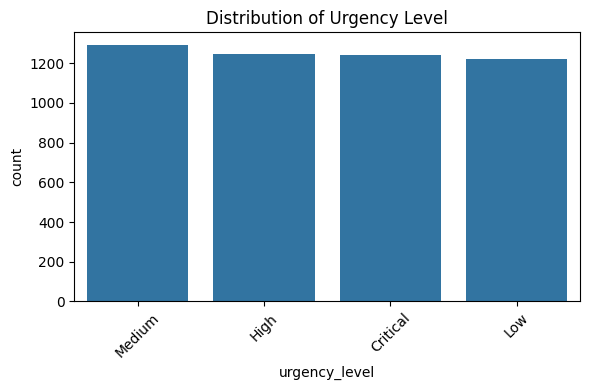

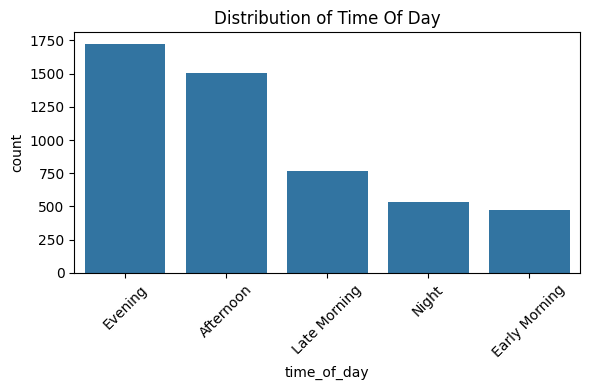

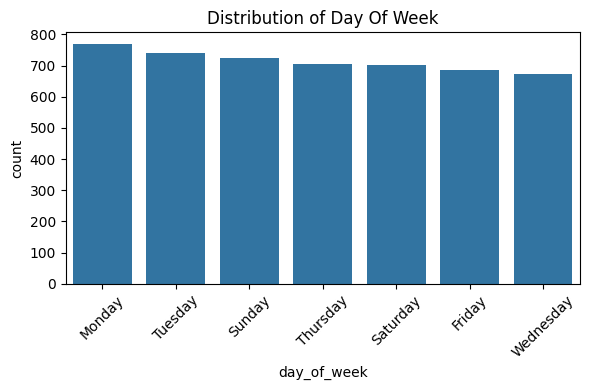

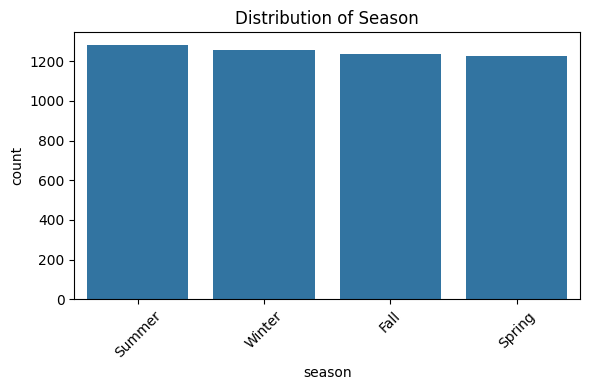

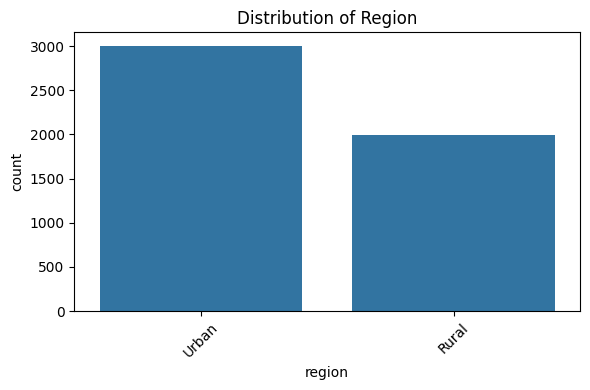

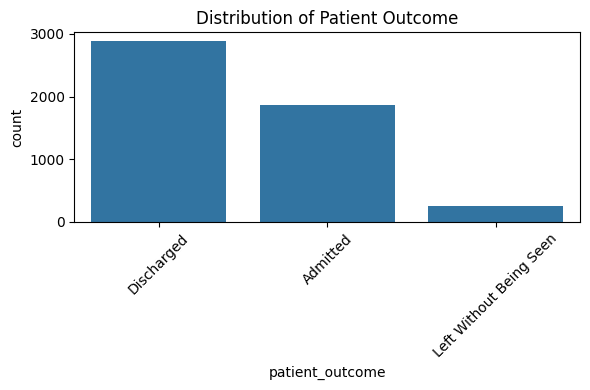

In [9]:
# Count plots for each categorical variable to check for class balance
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=er_data, x=col, order=er_data[col].value_counts().index)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

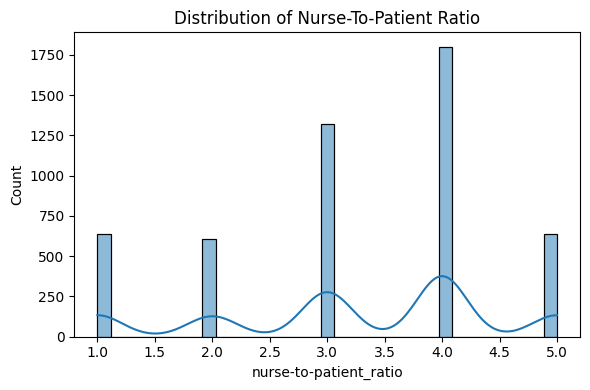

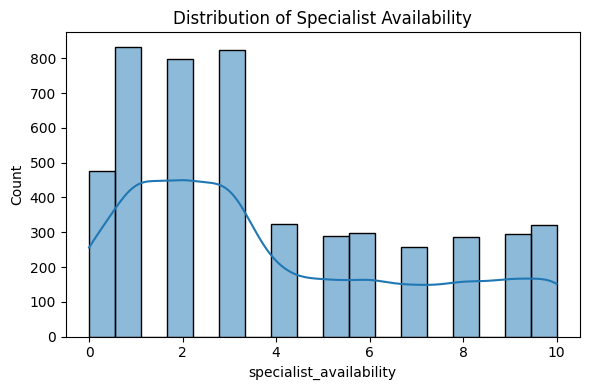

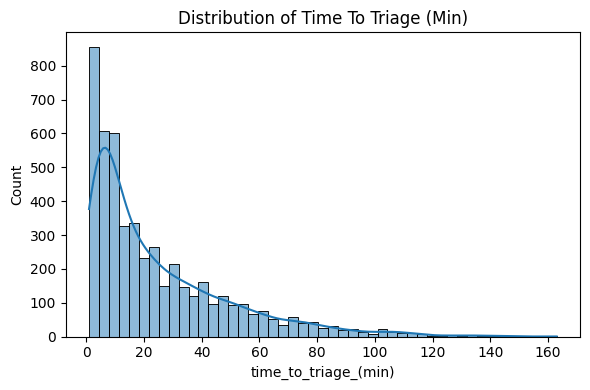

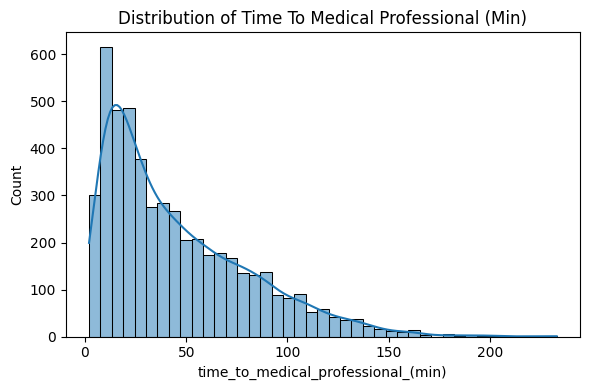

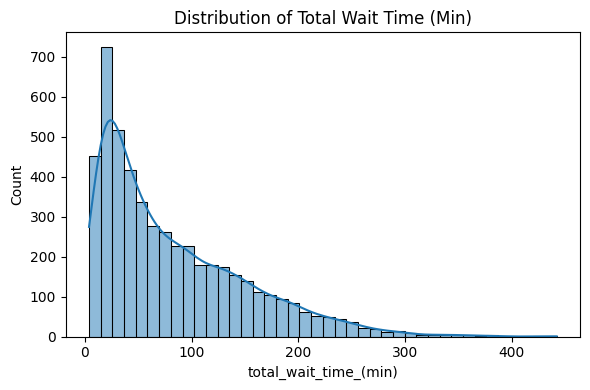

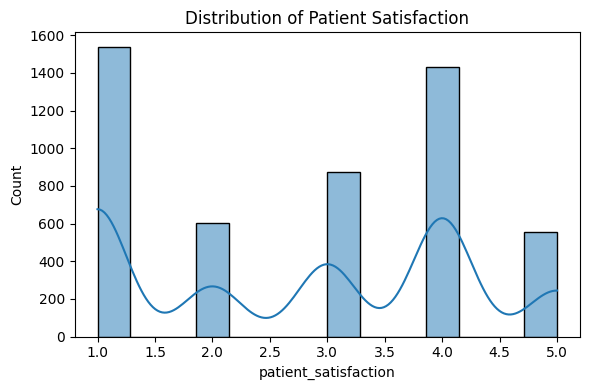

In [10]:
# Histograms with KDE for numerical features
numerical_cols = [
    'nurse-to-patient_ratio', 'specialist_availability',
    'time_to_triage_(min)', 'time_to_medical_professional_(min)',
    'total_wait_time_(min)', 'patient_satisfaction'
]

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=er_data, x=col, kde=True)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.tight_layout()
    plt.show()

## 6. Key Visualisations

Explore how urgency level, time of day, day of week, and season each relate to wait time.

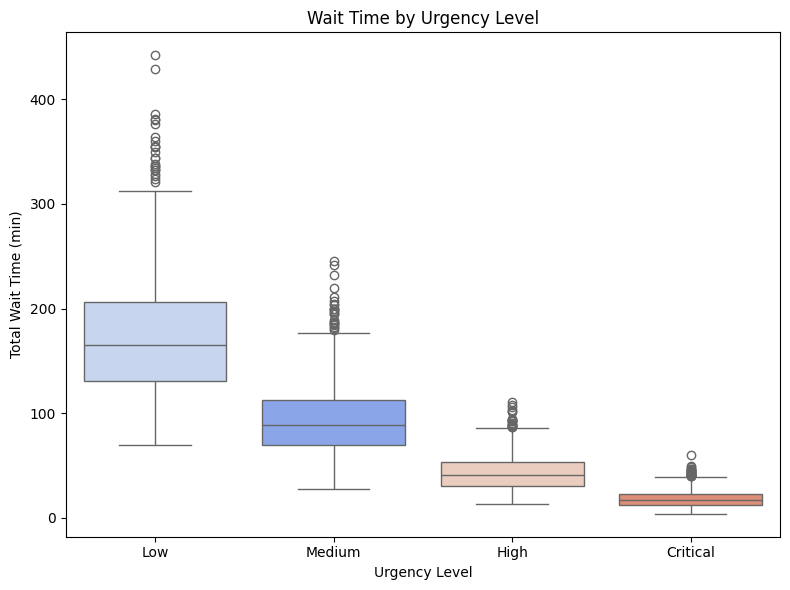

In [11]:
# Boxplot: Wait time distribution by urgency level
# Ordered Low → Critical to make the trend clear
urgency_order = ['Low', 'Medium', 'High', 'Critical']

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=er_data,
    x='urgency_level', y='total_wait_time_(min)',
    hue='urgency_level', palette='coolwarm',
    legend=False, order=urgency_order
)
plt.title('Wait Time by Urgency Level')
plt.ylabel('Total Wait Time (min)')
plt.xlabel('Urgency Level')
plt.tight_layout()
plt.show()

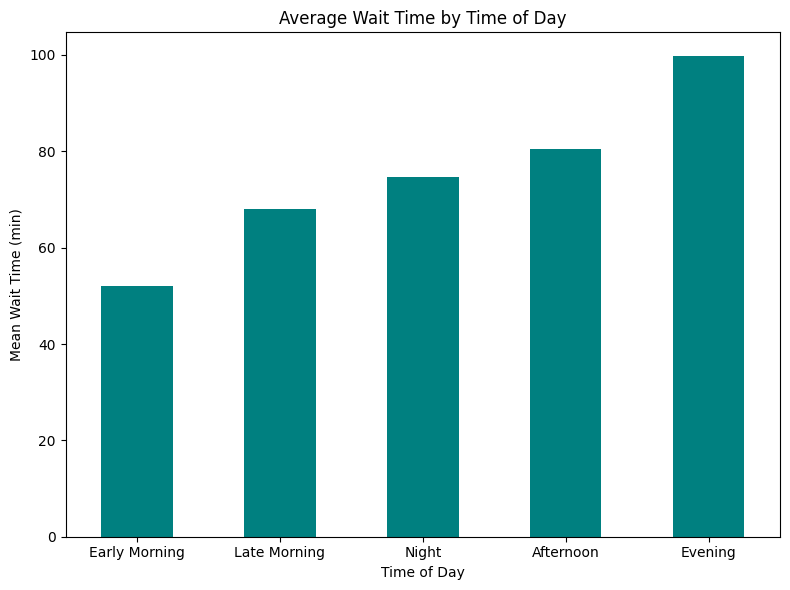

In [12]:
# Bar chart: Average wait time by time of day
# Sorted ascending to highlight which time period has the shortest/longest waits
plt.figure(figsize=(8, 6))
avg_by_time = er_data.groupby('time_of_day')['total_wait_time_(min)'].mean().sort_values()
avg_by_time.plot(kind='bar', color='teal')
plt.title('Average Wait Time by Time of Day')
plt.ylabel('Mean Wait Time (min)')
plt.xlabel('Time of Day')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

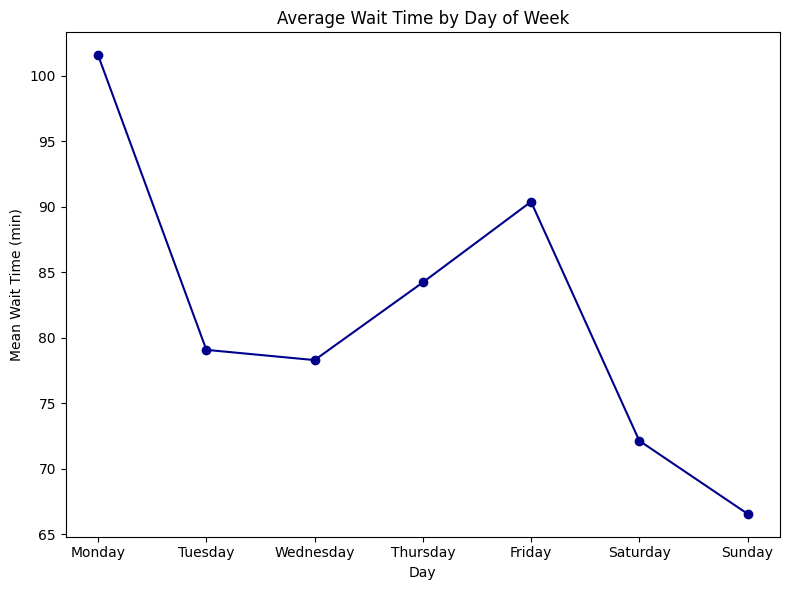

In [13]:
# Line chart: Average wait time across the week
# Reindexed to follow Mon–Sun order for readability
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_by_day = er_data.groupby('day_of_week')['total_wait_time_(min)'].mean().reindex(dow_order)

plt.figure(figsize=(8, 6))
avg_by_day.plot(marker='o', color='darkblue')
plt.title('Average Wait Time by Day of Week')
plt.ylabel('Mean Wait Time (min)')
plt.xlabel('Day')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

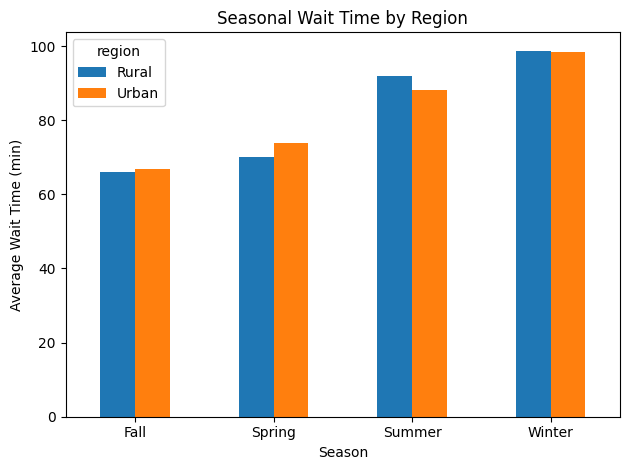

In [14]:
# Grouped bar chart: Seasonal wait time broken down by region
# Useful for identifying whether staffing patterns match seasonal demand across different areas
plt.figure(figsize=(10, 6))
season_region = er_data.groupby(['season', 'region'])['total_wait_time_(min)'].mean().unstack()
season_region.plot(kind='bar')
plt.title('Seasonal Wait Time by Region')
plt.ylabel('Average Wait Time (min)')
plt.xlabel('Season')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

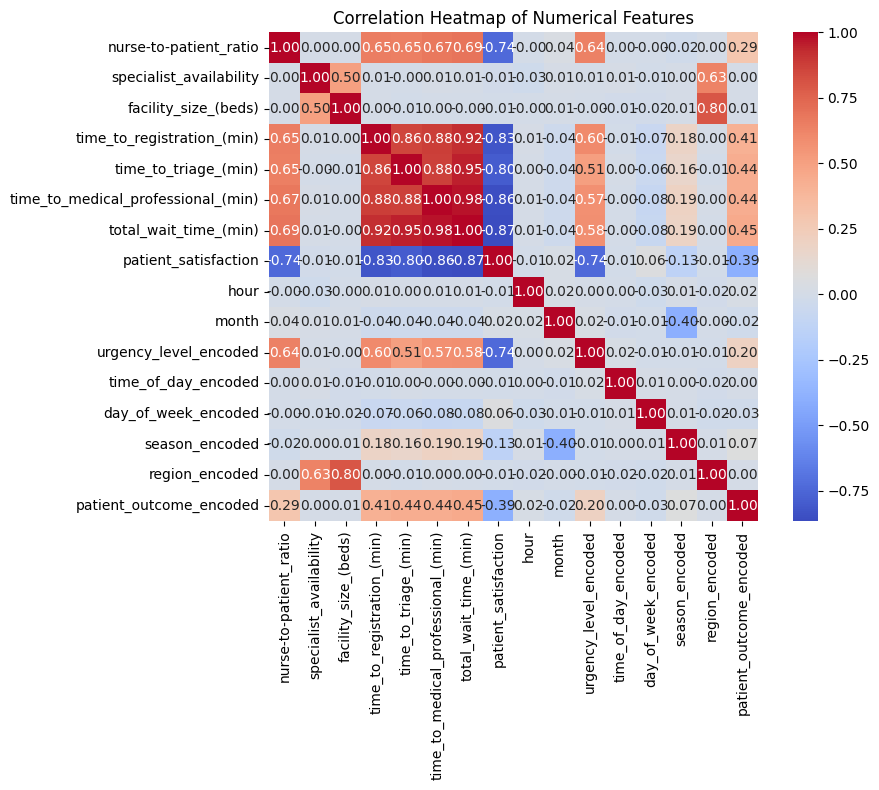

In [15]:
# Correlation heatmap of all numerical features
# Helps identify which features are most linearly related to total wait time
plt.figure(figsize=(10, 8))
num_corr = er_data.select_dtypes(include='number').corr()
sns.heatmap(num_corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

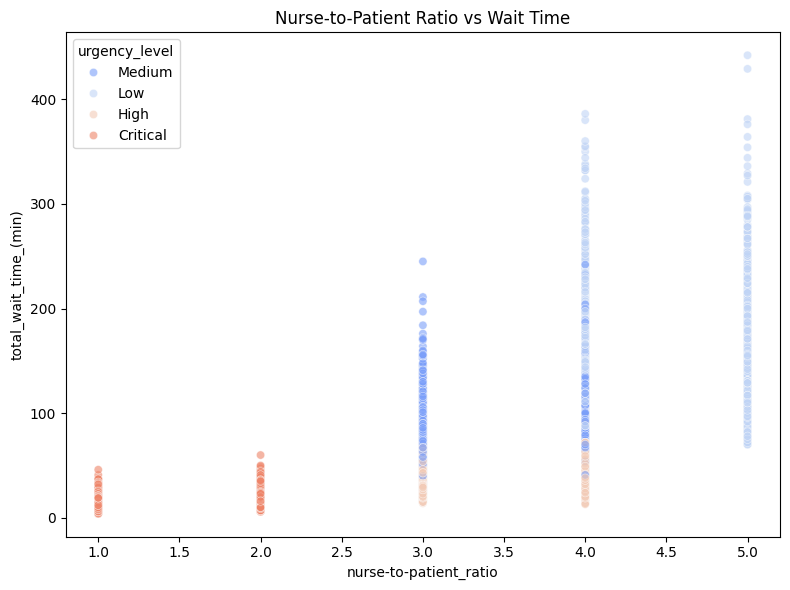

In [16]:
# Scatter plot: nurse-to-patient ratio vs wait time, coloured by urgency
# Explores whether staffing levels interact with urgency to affect wait time
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=er_data,
    x='nurse-to-patient_ratio', y='total_wait_time_(min)',
    hue='urgency_level', palette='coolwarm', alpha=0.6
)
plt.title('Nurse-to-Patient Ratio vs Wait Time')
plt.tight_layout()
plt.show()

## 7. Summary of Findings

| Finding | Observation |
|---------|-------------|
| **Urgency** | Critical patients wait significantly longer than Low urgency patients; urgency level is the strongest single driver of wait time |
| **Time of day** | Wait times are highest during evening hours |
| **Day of week** | Weekends tend to have longer average wait times than weekdays |
| **Seasonality** | Seasonal variation differs by region, suggesting staffing may not consistently match demand |
| **Staffing** | Nurse-to-patient ratio shows a relationship with wait time, particularly at higher urgency levels |

These findings inform the feature selection strategy for Part C (Predictive Modelling).

---
## Part 2 — Predictive Modelling

Building on the EDA findings above, we now select features, build a preprocessing pipeline, and compare two regression models to predict total ED wait time.

> **Note:** `time_to_triage` and `time_to_medical_professional` are excluded as features — they are partially derived from the target variable, which would cause data leakage.

In [17]:
# Additional imports for modelling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

## 8. Feature Selection

Based on EDA findings, we select:
- **Numerical features**: staffing indicators and temporal context
- **Categorical features**: urgency, time of day, day, season, region

`time_to_triage` and `time_to_medical_professional` are excluded as they are partially derived from the target, which would cause data leakage.

In [18]:
numerical_features   = ['nurse-to-patient_ratio', 'specialist_availability', 'hour', 'month']
categorical_features = ['urgency_level', 'time_of_day', 'day_of_week', 'season', 'region']
target               = 'total_wait_time_(min)'

X = er_data[numerical_features + categorical_features]
y = er_data[target]

print(f"Features: {X.shape[1]} | Samples: {X.shape[0]}")

Features: 9 | Samples: 5000


## 9. Preprocessing Pipeline

- **Numerical features**: standardised with `StandardScaler` (zero mean, unit variance)
- **Categorical features**: one-hot encoded with `drop='first'` to avoid multicollinearity

Both transformations are wrapped in a `ColumnTransformer` and composed into model pipelines, ensuring consistent preprocessing across train and test splits.

In [19]:
# Preprocessing: scale numerics, encode categoricals
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),               numerical_features),
    ('cat', OneHotEncoder(drop='first'),    categorical_features)
])

# Model 1: Linear Regression baseline
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor',    LinearRegression())
])

# Model 2: Random Forest — captures non-linear relationships
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor',    RandomForestRegressor(n_estimators=100, random_state=42))
])

## 10. Train / Test Split

In [20]:
# 80/20 split; random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 4000 samples | Test: 1000 samples


## 11. Model Training and Evaluation

In [21]:
# Train both models
linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Generate predictions
y_pred_lr = linear_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Compute RMSE and R² for each
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("Model Performance Summary")
print("-" * 45)
print(f"Linear Regression  — RMSE: {rmse_lr:.2f} | R²: {r2_lr:.4f}")
print(f"Random Forest      — RMSE: {rmse_rf:.2f} | R²: {r2_rf:.4f}")

Model Performance Summary
---------------------------------------------
Linear Regression  — RMSE: 24.75 | R²: 0.8683
Random Forest      — RMSE: 18.78 | R²: 0.9242


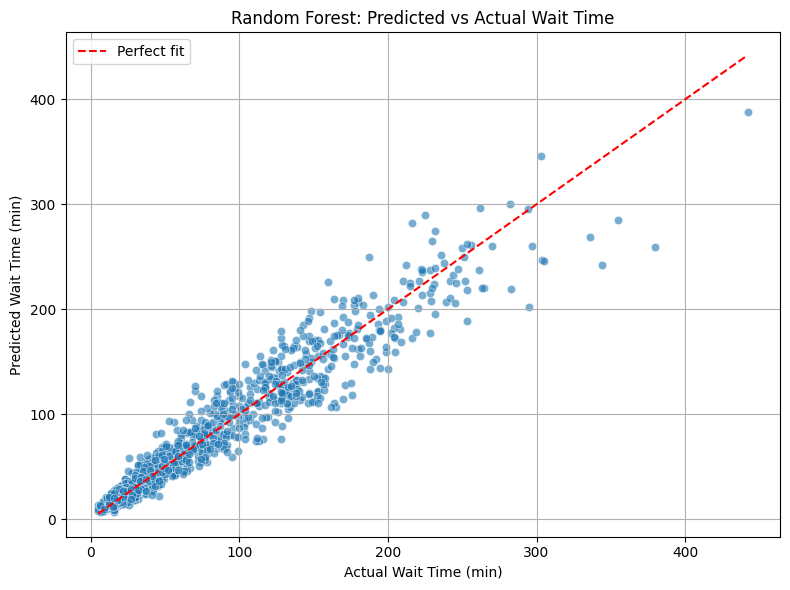

In [22]:
# Predicted vs Actual scatter for the better-performing model
# Points along the red diagonal = perfect predictions
best_preds      = y_pred_lr if r2_lr > r2_rf else y_pred_rf
best_model_name = 'Linear Regression' if r2_lr > r2_rf else 'Random Forest'

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=best_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect fit')
plt.title(f'{best_model_name}: Predicted vs Actual Wait Time')
plt.xlabel('Actual Wait Time (min)')
plt.ylabel('Predicted Wait Time (min)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 12. Hyperparameter Tuning (Random Forest)

We use `GridSearchCV` with 5-fold cross-validation to search over key Random Forest hyperparameters. This helps find the optimal configuration without overfitting to the test set.

In [23]:
# Hyperparameter search space
param_grid = {
    'regressor__n_estimators':    [50, 100, 150],   # Number of trees
    'regressor__max_depth':       [None, 10, 20],   # Max tree depth (None = fully grown)
    'regressor__min_samples_split': [2, 5, 10]      # Min samples to split a node
}

tuned_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

tuned_rf.fit(X_train, y_train)
print("Best parameters:", tuned_rf.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


Best parameters: {'regressor__max_depth': 10, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 150}


In [24]:
# Evaluate tuned model on the test set
best_rf    = tuned_rf.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

rmse_tuned = root_mean_squared_error(y_test, y_pred_tuned)
r2_tuned   = r2_score(y_test, y_pred_tuned)

print("\nTuned Random Forest Performance")
print("-" * 45)
print(f"RMSE: {rmse_tuned:.2f} | R²: {r2_tuned:.4f}")
print(f"\nImprovement over baseline RF — RMSE: {rmse_rf - rmse_tuned:.2f} | R²: {r2_tuned - r2_rf:.4f}")


Tuned Random Forest Performance
---------------------------------------------
RMSE: 18.37 | R²: 0.9274

Improvement over baseline RF — RMSE: 0.41 | R²: 0.0033


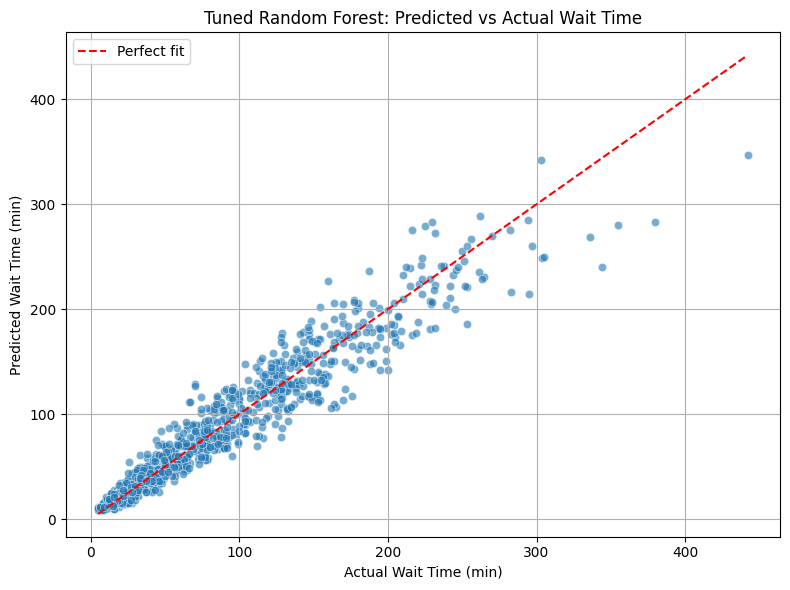

In [25]:
# Final predicted vs actual for tuned model
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect fit')
plt.title('Tuned Random Forest: Predicted vs Actual Wait Time')
plt.xlabel('Actual Wait Time (min)')
plt.ylabel('Predicted Wait Time (min)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

| Model | RMSE | R² |
|-------|------|----|
| Linear Regression | 24.75 | 0.8683 |
| Random Forest (baseline) | 18.78 | 0.9242 |
| Random Forest (tuned) | 18.37 | 0.9274 |

### Key Takeaways
- The tuned Random Forest achieved an R² of **0.9274**, explaining ~93% of the variance in ED wait times on this dataset
- Random Forest significantly outperforms Linear Regression (R² 0.9274 vs 0.8683), confirming non-linear relationships between staffing ratios and wait times
- Hyperparameter tuning (GridSearchCV) improved RMSE by 0.41 and R² by 0.0033 over the baseline Random Forest
- The strong R² on a synthetic dataset warrants caution — real-world performance on clinical data would require further validation
- Next steps would include feature importance analysis and testing on held-out hospital data from unseen regions